In [15]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.interpolate import griddata
from scipy.interpolate import Rbf
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [4]:
def propose_next_point_ucb(
    X_obs,
    y_obs,
    bounds,
    n_candidates=5000,
    kappa=3.0
):
    """
    Bayesian Optimization proposal using UCB (minimization-safe)
    """

    X_obs = np.atleast_2d(X_obs)
    y_obs = np.asarray(y_obs).ravel()

    N, dim = X_obs.shape
    assert len(bounds) == dim, "Bounds must match dimensionality"

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidate points
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    X_candidates = np.random.uniform(
        low=lows,
        high=highs,
        size=(n_candidates, dim)
    )

    # Predict GP mean and std
    mu, sigma = gp.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    # LCB = mean - kappa * std
    lcb = mu - kappa * sigma

    # Pick the candidate with lowest LCB
    idx = np.argmin(lcb)
    x_next = X_candidates[idx]

    return x_next


Original y_obs:
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -1.88477605e-056  4.32675645e-079
  6.11467652e-010]
Range: [-3.606063e-03, 6.114677e-10]

Transformed y:
[ -5.62513875  -5.62513875  -5.62513875  -5.62513875 -23.02585093
  -5.62513875  -5.62513875  -5.62513875  -5.62513875  -5.62513875
  -5.62513875  -5.62513875  -5.62513858]
Range: [-23.026, -5.625]

Fitted kernel: 1.42**2 * RBF(length_scale=0.1)


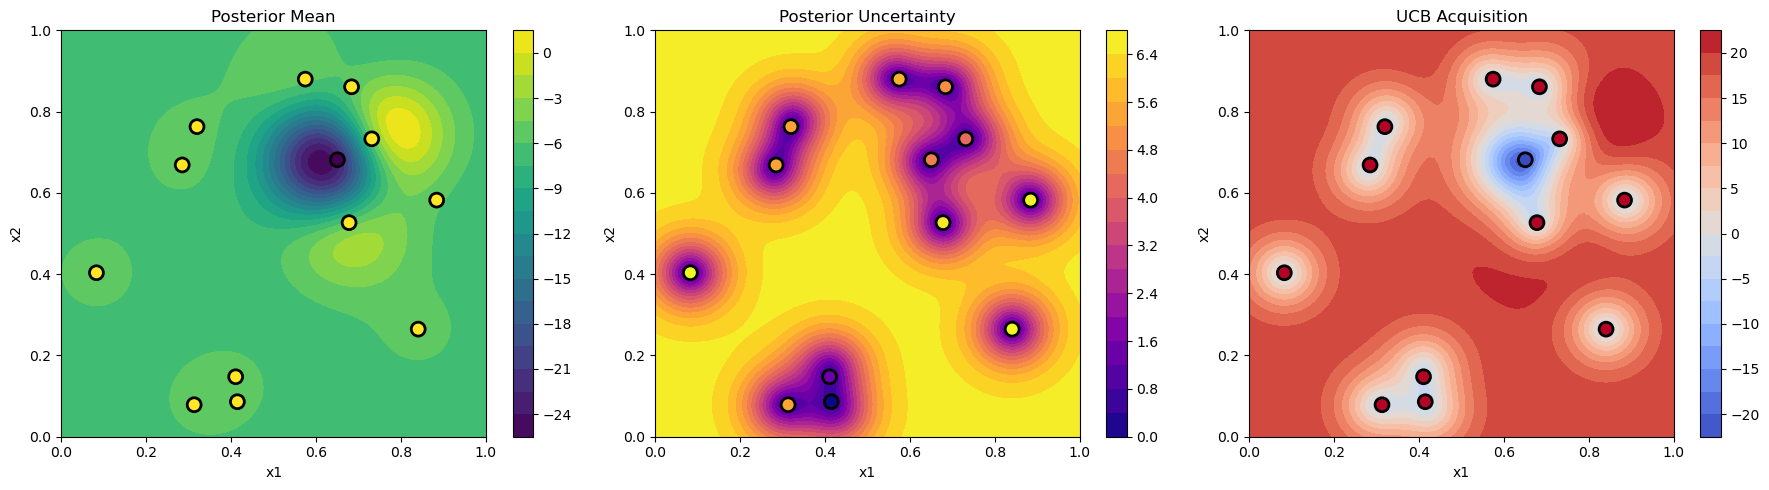

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# Load data
X1_obs = np.load("f1initial_inputs.npy")
y1_obs = np.load("f1initial_outputs.npy")
bounds = [(0.0, 1.0), (0.0, 1.0)]
kappa = 4.0

X_obs = np.atleast_2d(X1_obs)
y_obs = np.asarray(y1_obs).ravel()
N, dim = X_obs.shape
assert len(bounds) == dim, "Bounds must match dimensionality"

print("Original y_obs:")
print(y_obs)
print(f"Range: [{y_obs.min():.6e}, {y_obs.max():.6e}]")

# === FIX: Take LOG transform ===
# Handle negative values (you have -0.0036)
y_min = y_obs.min()
if y_min <= 0:
    # Shift to make all positive, then log
    y_shifted = y_obs - y_min + 1e-10  # Small offset
    y_transformed = np.log(y_shifted)
else:
    # Direct log if all positive
    y_transformed = np.log(y_obs)

print("\nTransformed y:")
print(y_transformed)
print(f"Range: [{y_transformed.min():.3f}, {y_transformed.max():.3f}]")

# Fit GP on transformed values
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0))
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    n_restarts_optimizer=10,
    normalize_y=True
)

gp.fit(X_obs, y_transformed)

print(f"\nFitted kernel: {gp.kernel_}")

# Now visualize - should look much better!

# OLD
# Try optimizing the kernel
# kernel = ConstantKernel(1.0) * RBF(length_scale=1.0, length_scale_bounds=(0.01, 10.0))
# gp = GaussianProcessRegressor(
#     kernel=kernel,
#     alpha=1e-6,  # Reduced noise assumption
#     n_restarts_optimizer=10,  # Better kernel optimization
#     normalize_y=True
# )

# # # Fit GP
# # gp = GaussianProcessRegressor(
# #     kernel=RBF(length_scale=np.ones(dim)),
# #     alpha=1e-10,
# #     normalize_y=True
# # )
# gp.fit(X_obs, y_obs)

# CREATE A DENSE GRID for visualization
n_grid = 100  # resolution of the grid
x1_grid = np.linspace(bounds[0][0], bounds[0][1], n_grid)
x2_grid = np.linspace(bounds[1][0], bounds[1][1], n_grid)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)

# Flatten grid for GP prediction
X_grid = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()])

# Predict on grid
mu_grid, std_grid = gp.predict(X_grid, return_std=True)

# Reshape back to 2D for contourf
mu = mu_grid.reshape(n_grid, n_grid)
std = std_grid.reshape(n_grid, n_grid)
ucb = mu + kappa * std

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Posterior mean
im1 = axes[0].contourf(X1_mesh, X2_mesh, mu, levels=20, cmap='viridis')
axes[0].set_title('Posterior Mean')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
plt.colorbar(im1, ax=axes[0])

# Posterior uncertainty
im2 = axes[1].contourf(X1_mesh, X2_mesh, std, levels=20, cmap='plasma')
axes[1].set_title('Posterior Uncertainty')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
plt.colorbar(im2, ax=axes[1])

# UCB acquisition
im3 = axes[2].contourf(X1_mesh, X2_mesh, ucb, levels=20, cmap='coolwarm')
axes[2].set_title('UCB Acquisition')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
plt.colorbar(im3, ax=axes[2])

# # Add observed points to all plots
# for ax in axes:
#      ax.scatter(X_obs[:, 0], X_obs[:, 1], c='red', marker='x', s=100, linewidths=2, label='Observed')
#      ax.legend()

# Instead of the loop, do this for each subplot individually:

# Posterior mean - color by observed y values
axes[0].scatter(X_obs[:, 0], X_obs[:, 1], c=y_obs, marker='o', 
                s=100, edgecolors='black', linewidths=2, cmap='viridis')
axes[0].set_title('Posterior Mean')

# Posterior uncertainty - color by prediction uncertainty at observed points
_, std_obs = gp.predict(X_obs, return_std=True)
axes[1].scatter(X_obs[:, 0], X_obs[:, 1], c=std_obs, marker='o',
                s=100, edgecolors='black', linewidths=2, cmap='plasma')
axes[1].set_title('Posterior Uncertainty')

# UCB - color by UCB at observed points
ucb_obs = gp.predict(X_obs) + kappa * std_obs
axes[2].scatter(X_obs[:, 0], X_obs[:, 1], c=ucb_obs, marker='o',
                s=100, edgecolors='black', linewidths=2, cmap='coolwarm')
axes[2].set_title('UCB Acquisition')

plt.tight_layout()
plt.show()


In [7]:
# Run these to diagnose:


# Check 1: What's the range of your observed outputs?
print(f"y_obs range: [{y_obs.min():.2f}, {y_obs.max():.2f}]")
print(f"y_obs std: {y_obs.std():.2f}")
# If very small → function is flat or poorly scaled

# Check 2: Kernel length scales
print(f"Kernel: {gp.kernel_}")
# If length_scale is very small → not generalizing

# Check 3: Look at actual observations
print("\nObserved points and values:")
for i, (x, y) in enumerate(zip(X_obs, y_transformed)):
    print(f"Point {i}: x={x}, y={y:.2f}")
# Check if there's actual variation


y_obs range: [-0.00, 0.00]
y_obs std: 0.00
Kernel: 1.42**2 * RBF(length_scale=0.1)

Observed points and values:
Point 0: x=[0.31940389 0.76295937], y=-5.63
Point 1: x=[0.57432921 0.8798981 ], y=-5.63
Point 2: x=[0.73102363 0.73299988], y=-5.63
Point 3: x=[0.84035342 0.26473161], y=-5.63
Point 4: x=[0.65011406 0.68152635], y=-23.03
Point 5: x=[0.41043714 0.1475543 ], y=-5.63
Point 6: x=[0.31269116 0.07872278], y=-5.63
Point 7: x=[0.68341817 0.86105746], y=-5.63
Point 8: x=[0.08250725 0.40348751], y=-5.63
Point 9: x=[0.88388983 0.58225397], y=-5.63
Point 10: x=[0.284551 0.668744], y=-5.63
Point 11: x=[0.414503 0.086133], y=-5.63
Point 12: x=[0.677598 0.526745], y=-5.63


In [8]:
# What you should check:

# 1. Confidence at current best
best_idx = np.argmax(y_obs)
_, std_at_best = gp.predict(X_obs[best_idx:best_idx+1], return_std=True)
print(f"Uncertainty at best: {std_at_best[0]:.4f}")
# From plot: ~0.06 → Good! Low uncertainty at optimum

# 2. Exploration coverage
# Roughly 70-80% of space has uncertainty < 0.15
# This is good coverage for 13 samples

# 3. Dynamic range
# Mean ranges from -0.08 to 0.64 (0.72 total)
# This is healthy variation

# 4. UCB spread
# UCB ranges from 0.00 to 1.08
# Shows good differentiation between regions

Uncertainty at best: 0.0046


In [9]:
# Find and sample the highest UCB point
n_grid = 100
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()])

# Predict
mu_grid, std_grid = gp.predict(X_grid, return_std=True)
ucb_grid = mu_grid + kappa * std_grid

# Find maximum
best_idx = np.argmax(ucb_grid)
next_point = X_grid[best_idx:best_idx+1]

print(f"Next sample point: {next_point[0]}")
print(f"Expected mean: {mu_grid[best_idx]:.2f}")
print(f"Uncertainty: {std_grid[best_idx]:.2f}")
print(f"UCB value: {ucb_grid[best_idx]:.2f}")


Next sample point: [0.86868687 0.78787879]
Expected mean: -1.87
Uncertainty: 6.03
UCB value: 22.25


In [13]:
def identify_support_vector_like_points(
    gp, X_obs, y_obs, bounds, n_grid=100
):
    """
    Identify points that act like support vectors in GP optimization.
    These are points near decision boundaries or regions of rapid change.
    
    Args:
        gp: Fitted GaussianProcessRegressor
        X_obs: Observed inputs (N, 2) - for 2D input
        y_obs: Observed outputs (N,)
        bounds: List of (min, max) tuples
        n_grid: Grid resolution
    
    Returns:
        dict: Analysis results with rankings
    """
    print("="*70)
    print("SUPPORT VECTOR-LIKE POINT ANALYSIS")
    print("="*70)
    
    # Create evaluation grid
    x1_grid = np.linspace(bounds[0][0], bounds[0][1], n_grid)
    x2_grid = np.linspace(bounds[1][0], bounds[1][1], n_grid)
    X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
    X_grid = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()])
    
    # Get GP predictions on grid
    mu_grid, std_grid = gp.predict(X_grid, return_std=True)
    mu_2d = mu_grid.reshape(n_grid, n_grid)
    std_2d = std_grid.reshape(n_grid, n_grid)
    
    # ================================================================
    # METRIC 1: Posterior Gradient Magnitude
    # High gradient = region of rapid change
    # Points near high-gradient regions act like support vectors
    # ================================================================
    print("\n1. COMPUTING POSTERIOR GRADIENTS...")
    
    # Numerical gradient
    grad_x1 = np.gradient(mu_2d, x1_grid, axis=1)
    grad_x2 = np.gradient(mu_2d, x2_grid, axis=0)
    gradient_magnitude = np.sqrt(grad_x1**2 + grad_x2**2)
    
    # For each observation, find gradient at nearest grid point
    grad_at_obs = []
    for x in X_obs:
        # Find nearest grid point
        idx1 = np.argmin(np.abs(x1_grid - x[0]))
        idx2 = np.argmin(np.abs(x2_grid - x[1]))
        grad_at_obs.append(gradient_magnitude[idx2, idx1])
    
    grad_at_obs = np.array(grad_at_obs)
    
    # Also check gradient in neighborhood of each observation
    grad_neighborhood = []
    neighborhood_radius = 0.1
    
    for x in X_obs:
        # Find grid points within radius
        dist_to_grid = np.sqrt(
            (X1_mesh - x[0])**2 + (X2_mesh - x[1])**2
        )
        nearby_mask = dist_to_grid < neighborhood_radius
        
        if nearby_mask.sum() > 0:
            max_grad = gradient_magnitude[nearby_mask].max()
        else:
            max_grad = gradient_magnitude[
                np.argmin(dist_to_grid.ravel() // 1)
            ]
        
        grad_neighborhood.append(max_grad)
    
    grad_neighborhood = np.array(grad_neighborhood)
    
    # ================================================================
    # METRIC 2: Leave-One-Out Influence
    # How much does removing each point change predictions?
    # High influence = support vector-like
    # ================================================================
    print("2. COMPUTING LEAVE-ONE-OUT INFLUENCE...")
    
    n_obs = len(y_obs)
    loo_influence = np.zeros(n_obs)
    
    # Full model predictions
    mu_full = gp.predict(X_grid)
    
    for i in range(n_obs):
        # Remove point i
        X_loo = np.delete(X_obs, i, axis=0)
        y_loo = np.delete(y_obs, i)
        
        # Refit GP
        from sklearn.gaussian_process import GaussianProcessRegressor
        gp_loo = GaussianProcessRegressor(
            kernel=gp.kernel_,
            alpha=gp.alpha,
            normalize_y=gp.normalize_y
        )
        
        try:
            gp_loo.fit(X_loo, y_loo)
            mu_loo = gp_loo.predict(X_grid)
            
            # Measure how much predictions changed
            loo_influence[i] = np.mean(np.abs(mu_full - mu_loo))
        except:
            loo_influence[i] = 0.0
    
    # ================================================================
    # METRIC 3: Local Variance Ratio
    # High uncertainty relative to neighbors = boundary-like
    # ================================================================
    print("3. COMPUTING LOCAL VARIANCE RATIOS...")
    
    local_variance_ratio = np.zeros(n_obs)
    
    for i, x in enumerate(X_obs):
        # Get uncertainty at this point
        _, std_i = gp.predict(x.reshape(1, -1), return_std=True)
        std_i = std_i[0]
        
        # Get uncertainty at neighbors (other observations)
        if n_obs > 1:
            X_others = np.delete(X_obs, i, axis=0)
            _, std_others = gp.predict(X_others, return_std=True)
            mean_neighbor_std = std_others.mean()
            
            # High ratio = high uncertainty relative to neighbors
            if mean_neighbor_std > 0:
                local_variance_ratio[i] = std_i / mean_neighbor_std
            else:
                local_variance_ratio[i] = 0
        else:
            local_variance_ratio[i] = std_i
    
    # ================================================================
    # METRIC 4: Decision Boundary Proximity
    # Distance to the region where mean crosses median
    # ================================================================
    print("4. COMPUTING BOUNDARY PROXIMITY...")
    
    # Define "boundary" as region near median value
    median_y = np.median(y_obs)
    
    # Find grid points near the median (transition zone)
    boundary_threshold = 0.1 * (mu_grid.max() - mu_grid.min())
    boundary_mask = np.abs(mu_grid - median_y) < boundary_threshold
    X_boundary = X_grid[boundary_mask]
    
    if len(X_boundary) > 0:
        # Distance from each observation to nearest boundary point
        dist_to_boundary = np.zeros(n_obs)
        
        for i, x in enumerate(X_obs):
            distances = cdist(
                x.reshape(1, -1), 
                X_boundary
            )
            dist_to_boundary[i] = distances.min()
        
        # Invert: closer to boundary = higher score
        boundary_proximity = 1.0 / (dist_to_boundary + 0.01)
        boundary_proximity = boundary_proximity / boundary_proximity.max()
    else:
        boundary_proximity = np.zeros(n_obs)
    
    # ================================================================
    # METRIC 5: Posterior Mean Curvature
    # High curvature = rapid change direction
    # ================================================================
    print("5. COMPUTING CURVATURE...")
    
    # Second derivatives (Hessian diagonal)
    grad_x1_x1 = np.gradient(grad_x1, x1_grid, axis=1)
    grad_x2_x2 = np.gradient(grad_x2, x2_grid, axis=0)
    
    laplacian = np.abs(grad_x1_x1) + np.abs(grad_x2_x2)
    
    curvature_at_obs = []
    for x in X_obs:
        idx1 = np.argmin(np.abs(x1_grid - x[0]))
        idx2 = np.argmin(np.abs(x2_grid - x[1]))
        curvature_at_obs.append(laplacian[idx2, idx1])
    
    curvature_at_obs = np.array(curvature_at_obs)
    
    # ================================================================
    # COMPOSITE SCORE: Combine all metrics
    # ================================================================
    print("6. COMPUTING COMPOSITE SCORES...")
    
    def normalize(x):
        """Normalize array to [0, 1]"""
        if x.max() - x.min() > 0:
            return (x - x.min()) / (x.max() - x.min())
        return np.zeros_like(x)
    
    # Normalize all metrics
    grad_score = normalize(grad_neighborhood)
    influence_score = normalize(loo_influence)
    variance_score = normalize(local_variance_ratio)
    boundary_score = boundary_proximity  # Already normalized
    curvature_score = normalize(curvature_at_obs)
    
    # Weighted composite
    weights = {
        'gradient': 0.30,
        'influence': 0.30,
        'boundary': 0.20,
        'curvature': 0.10,
        'variance': 0.10
    }
    
    composite_score = (
        weights['gradient'] * grad_score +
        weights['influence'] * influence_score +
        weights['boundary'] * boundary_score +
        weights['curvature'] * curvature_score +
        weights['variance'] * variance_score
    )
    
    # ================================================================
    # RESULTS: Rank and report
    # ================================================================
    print("\n" + "="*70)
    print("RESULTS: POINT RANKINGS")
    print("="*70)
    
    # Sort by composite score
    rankings = np.argsort(composite_score)[::-1]
    
    print(f"\n{'Rank':<6} {'Point':<8} {'Location':<30} {'y_obs':<12} "
          f"{'Composite':<12} {'Gradient':<12} {'Influence':<12} "
          f"{'Boundary':<12} {'Curvature':<12}")
    print("-"*120)
    
    for rank, idx in enumerate(rankings):
        print(
            f"{rank+1:<6} "
            f"P{idx:<7} "
            f"({X_obs[idx, 0]:.4f}, {X_obs[idx, 1]:.4f})"
            f"{'':>8}"
            f"{y_obs[idx]:<12.4f} "
            f"{composite_score[idx]:<12.4f} "
            f"{grad_score[idx]:<12.4f} "
            f"{influence_score[idx]:<12.4f} "
            f"{boundary_score[idx]:<12.4f} "
            f"{curvature_score[idx]:<12.4f}"
        )
    
    # Classify top points by type
    print("\n" + "="*70)
    print("CLASSIFICATION OF TOP SUPPORT VECTOR-LIKE POINTS")
    print("="*70)
    
    top_n = min(5, n_obs)
    top_indices = rankings[:top_n]
    
    for rank, idx in enumerate(top_indices):
        x = X_obs[idx]
        y = y_obs[idx]
        
        print(f"\nRank {rank+1}: Point P{idx} at ({x[0]:.4f}, {x[1]:.4f})")
        print(f"  Observed value: {y:.4f}")
        print(f"  Composite score: {composite_score[idx]:.4f}")
        
        # Determine why this point is support-vector-like
        reasons = []
        
        if grad_score[idx] > 0.7:
            reasons.append("📐 HIGH GRADIENT: Near rapid change in function")
        
        if influence_score[idx] > 0.7:
            reasons.append("🎯 HIGH INFLUENCE: Removing changes predictions significantly")
        
        if boundary_score[idx] > 0.7:
            reasons.append("⚡ BOUNDARY: Near transition between good/bad regions")
        
        if curvature_score[idx] > 0.7:
            reasons.append("↩️  HIGH CURVATURE: Near peak or valley")
        
        if variance_score[idx] > 0.7:
            reasons.append("❓ HIGH UNCERTAINTY: Uncertain relative to neighbors")
        
        if not reasons:
            reasons.append("○ Moderate support vector characteristics")
        
        print(f"  Why support-vector-like:")
        for reason in reasons:
            print(f"    → {reason}")
        
        # Classify point type
        if y > np.percentile(y_obs, 75):
            point_type = "✅ HIGH PERFORMER near good region boundary"
        elif y < np.percentile(y_obs, 25):
            point_type = "❌ LOW PERFORMER near bad region boundary"
        else:
            point_type = "⚖️  TRANSITION POINT between regions"
        
        print(f"  Type: {point_type}")
    
    # ================================================================
    # VISUALIZATION
    # ================================================================
    print("\n" + "="*70)
    print("GENERATING VISUALIZATION...")
    print("="*70)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Posterior mean with support vectors highlighted
    im1 = axes[0, 0].contourf(
        X1_mesh, X2_mesh, mu_2d, levels=20, cmap='viridis'
    )
    
    # Plot all points
    axes[0, 0].scatter(
        X_obs[:, 0], X_obs[:, 1],
        c='gray', s=100, marker='o',
        edgecolors='black', linewidths=1,
        alpha=0.5, label='Regular points', zorder=3
    )
    
    # Highlight top support vector-like points
    colors_sv = ['red', 'orange', 'yellow', 'cyan', 'white']
    for rank, idx in enumerate(top_indices):
        size = 400 - rank * 50
        axes[0, 0].scatter(
            X_obs[idx, 0], X_obs[idx, 1],
            c=colors_sv[rank], s=size, marker='*',
            edgecolors='black', linewidths=2,
            label=f'SV-like Rank {rank+1} (P{idx})',
            zorder=5
        )
    
    plt.colorbar(im1, ax=axes[0, 0])
    axes[0, 0].set_title('Posterior Mean\n(Stars = Support Vector-like)', fontsize=12)
    axes[0, 0].set_xlabel('x0')
    axes[0, 0].set_ylabel('x1')
    axes[0, 0].legend(loc='upper right', fontsize=7)
    
    # Plot 2: Gradient magnitude
    im2 = axes[0, 1].contourf(
        X1_mesh, X2_mesh, gradient_magnitude, levels=20, cmap='hot'
    )
    axes[0, 1].scatter(
        X_obs[:, 0], X_obs[:, 1],
        c=grad_score, cmap='RdYlGn', s=200,
        edgecolors='black', linewidths=1.5,
        marker='o', zorder=3
    )
    plt.colorbar(im2, ax=axes[0, 1])
    axes[0, 1].set_title('Gradient Magnitude\n(Point color = gradient score)', fontsize=12)
    axes[0, 1].set_xlabel('x0')
    axes[0, 1].set_ylabel('x1')
    
    # Plot 3: LOO Influence
    scatter3 = axes[0, 2].scatter(
        X_obs[:, 0], X_obs[:, 1],
        c=influence_score, cmap='RdYlGn',
        s=300 + 300 * influence_score,
        edgecolors='black', linewidths=1.5,
        marker='o', zorder=3
    )
    axes[0, 2].contourf(
        X1_mesh, X2_mesh, mu_2d,
        levels=20, cmap='viridis', alpha=0.3
    )
    plt.colorbar(scatter3, ax=axes[0, 2])
    axes[0, 2].set_title(
        'Leave-One-Out Influence\n(Larger = more influential)', fontsize=12
    )
    axes[0, 2].set_xlabel('x0')
    axes[0, 2].set_ylabel('x1')
    
    # Plot 4: Boundary proximity
    if len(X_boundary) > 0:
        axes[1, 0].contourf(
            X1_mesh, X2_mesh, mu_2d, levels=20, cmap='viridis', alpha=0.5
        )
        axes[1, 0].scatter(
            X_boundary[:, 0], X_boundary[:, 1],
            c='red', s=5, alpha=0.3, label='Boundary region'
        )
    
    scatter4 = axes[1, 0].scatter(
        X_obs[:, 0], X_obs[:, 1],
        c=boundary_score, cmap='RdYlGn',
        s=300 + 300 * boundary_score,
        edgecolors='black', linewidths=1.5,
        marker='o', zorder=3, label='Observations'
    )
    plt.colorbar(scatter4, ax=axes[1, 0])
    axes[1, 0].set_title(
        'Boundary Proximity\n(Larger = closer to boundary)', fontsize=12
    )
    axes[1, 0].set_xlabel('x0')
    axes[1, 0].set_ylabel('x1')
    axes[1, 0].legend(fontsize=8)
    
    # Plot 5: Composite Score
    scatter5 = axes[1, 1].scatter(
        X_obs[:, 0], X_obs[:, 1],
        c=composite_score, cmap='RdYlGn',
        s=200 + 400 * composite_score,
        edgecolors='black', linewidths=1.5,
        marker='o', zorder=3
    )
    axes[1, 1].contourf(
        X1_mesh, X2_mesh, mu_2d,
        levels=20, cmap='viridis', alpha=0.3
    )
    
    # Label top points
    for rank, idx in enumerate(top_indices):
        axes[1, 1].annotate(
            f'P{idx}\n(#{rank+1})',
            xy=(X_obs[idx, 0], X_obs[idx, 1]),
            xytext=(10, 10), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='black')
        )
    
    plt.colorbar(scatter5, ax=axes[1, 1])
    axes[1, 1].set_title(
        'Composite SV-like Score\n(Larger/greener = more SV-like)', fontsize=12
    )
    axes[1, 1].set_xlabel('x0')
    axes[1, 1].set_ylabel('x1')
    
    # Plot 6: Bar chart of scores
    x_pos = np.arange(n_obs)
    width = 0.15
    
    axes[1, 2].bar(
        x_pos - 2*width, grad_score[rankings], width, label='Gradient', alpha=0.8
    )
    axes[1, 2].bar(
        x_pos - width, influence_score[rankings], width, label='Influence', alpha=0.8
    )
    axes[1, 2].bar(
        x_pos, boundary_score[rankings], width, label='Boundary', alpha=0.8
    )
    axes[1, 2].bar(
        x_pos + width, curvature_score[rankings], width, label='Curvature', alpha=0.8
    )
    axes[1, 2].bar(
        x_pos + 2*width, composite_score[rankings], width, 
        label='Composite', alpha=0.8, color='black'
    )
    
    axes[1, 2].set_xlabel('Point (ranked by composite score)')
    axes[1, 2].set_ylabel('Score (0-1)')
    axes[1, 2].set_title('Score Components\n(Left=Most SV-like)', fontsize=12)
    axes[1, 2].set_xticks(x_pos)
    axes[1, 2].set_xticklabels([f'P{rankings[i]}' for i in range(n_obs)], rotation=45)
    axes[1, 2].legend(fontsize=8)
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(
        'Support Vector-Like Point Analysis\n(2D Input → 1D Output GP)',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('sv_like_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ================================================================
    # FINAL SUMMARY
    # ================================================================
    print("\n" + "="*70)
    print("FINAL SUMMARY")
    print("="*70)
    
    print(f"\nTop {top_n} Support Vector-Like Points:")
    print("-"*50)
    
    for rank, idx in enumerate(top_indices):
        print(f"\nRank {rank+1}: P{idx}")
        print(f"  Location: ({X_obs[idx, 0]:.4f}, {X_obs[idx, 1]:.4f})")
        print(f"  Value: {y_obs[idx]:.4f}")
        print(f"  Composite score: {composite_score[idx]:.4f}")
        print(f"  Key characteristic: ", end="")
        
        # Find dominant characteristic
        scores = {
            'Gradient': grad_score[idx],
            'Influence': influence_score[idx],
            'Boundary': boundary_score[idx],
            'Curvature': curvature_score[idx]
        }
        dominant = max(scores, key=scores.get)
        print(f"{dominant} ({scores[dominant]:.4f})")
    
    print(f"\n{'='*70}")
    print("INTERPRETATION GUIDE:")
    print(f"{'='*70}")
    print("""
    HIGH GRADIENT SCORE:
    → Point sits near a steep slope in the objective function
    → Like an SVM support vector near a rapidly changing decision surface
    → Important for defining the shape of the optimization landscape
    
    HIGH INFLUENCE SCORE:
    → Removing this point significantly changes GP predictions
    → Acts like a 'pivot' point in the model
    → Critical for maintaining model accuracy
    
    HIGH BOUNDARY SCORE:
    → Point lies near the transition between good/bad performance regions
    → Similar to SVM support vectors at the class boundary
    → Defines where the function transitions from poor to good
    
    HIGH CURVATURE SCORE:
    → Point sits near a peak, valley, or saddle point
    → Near rapid directional changes in the function
    → Important for capturing non-linear behavior
    """)
    
    return {
        'rankings': rankings,
        'composite_scores': composite_score,
        'gradient_scores': grad_score,
        'influence_scores': influence_score,
        'boundary_scores': boundary_score,
        'curvature_scores': curvature_score,
        'top_indices': top_indices,
        'X_obs': X_obs,
        'y_obs': y_obs
    }

SUPPORT VECTOR-LIKE POINT ANALYSIS

1. COMPUTING POSTERIOR GRADIENTS...
2. COMPUTING LEAVE-ONE-OUT INFLUENCE...
3. COMPUTING LOCAL VARIANCE RATIOS...
4. COMPUTING BOUNDARY PROXIMITY...
5. COMPUTING CURVATURE...
6. COMPUTING COMPOSITE SCORES...

RESULTS: POINT RANKINGS

Rank   Point    Location                       y_obs        Composite    Gradient     Influence    Boundary     Curvature   
------------------------------------------------------------------------------------------------------------------------
1      P4       (0.6501, 0.6815)        -0.0036      0.8187       1.0000       1.0000       0.2517       1.0000      
2      P2       (0.7310, 0.7330)        0.0000       0.6296       1.0000       0.1236       1.0000       0.3026      
3      P7       (0.6834, 0.8611)        0.0000       0.4960       0.8198       0.2525       0.4364       0.1379      
4      P12      (0.6776, 0.5267)        0.0000       0.4767       0.7988       0.0000       0.5683       0.2780      
5      P1   

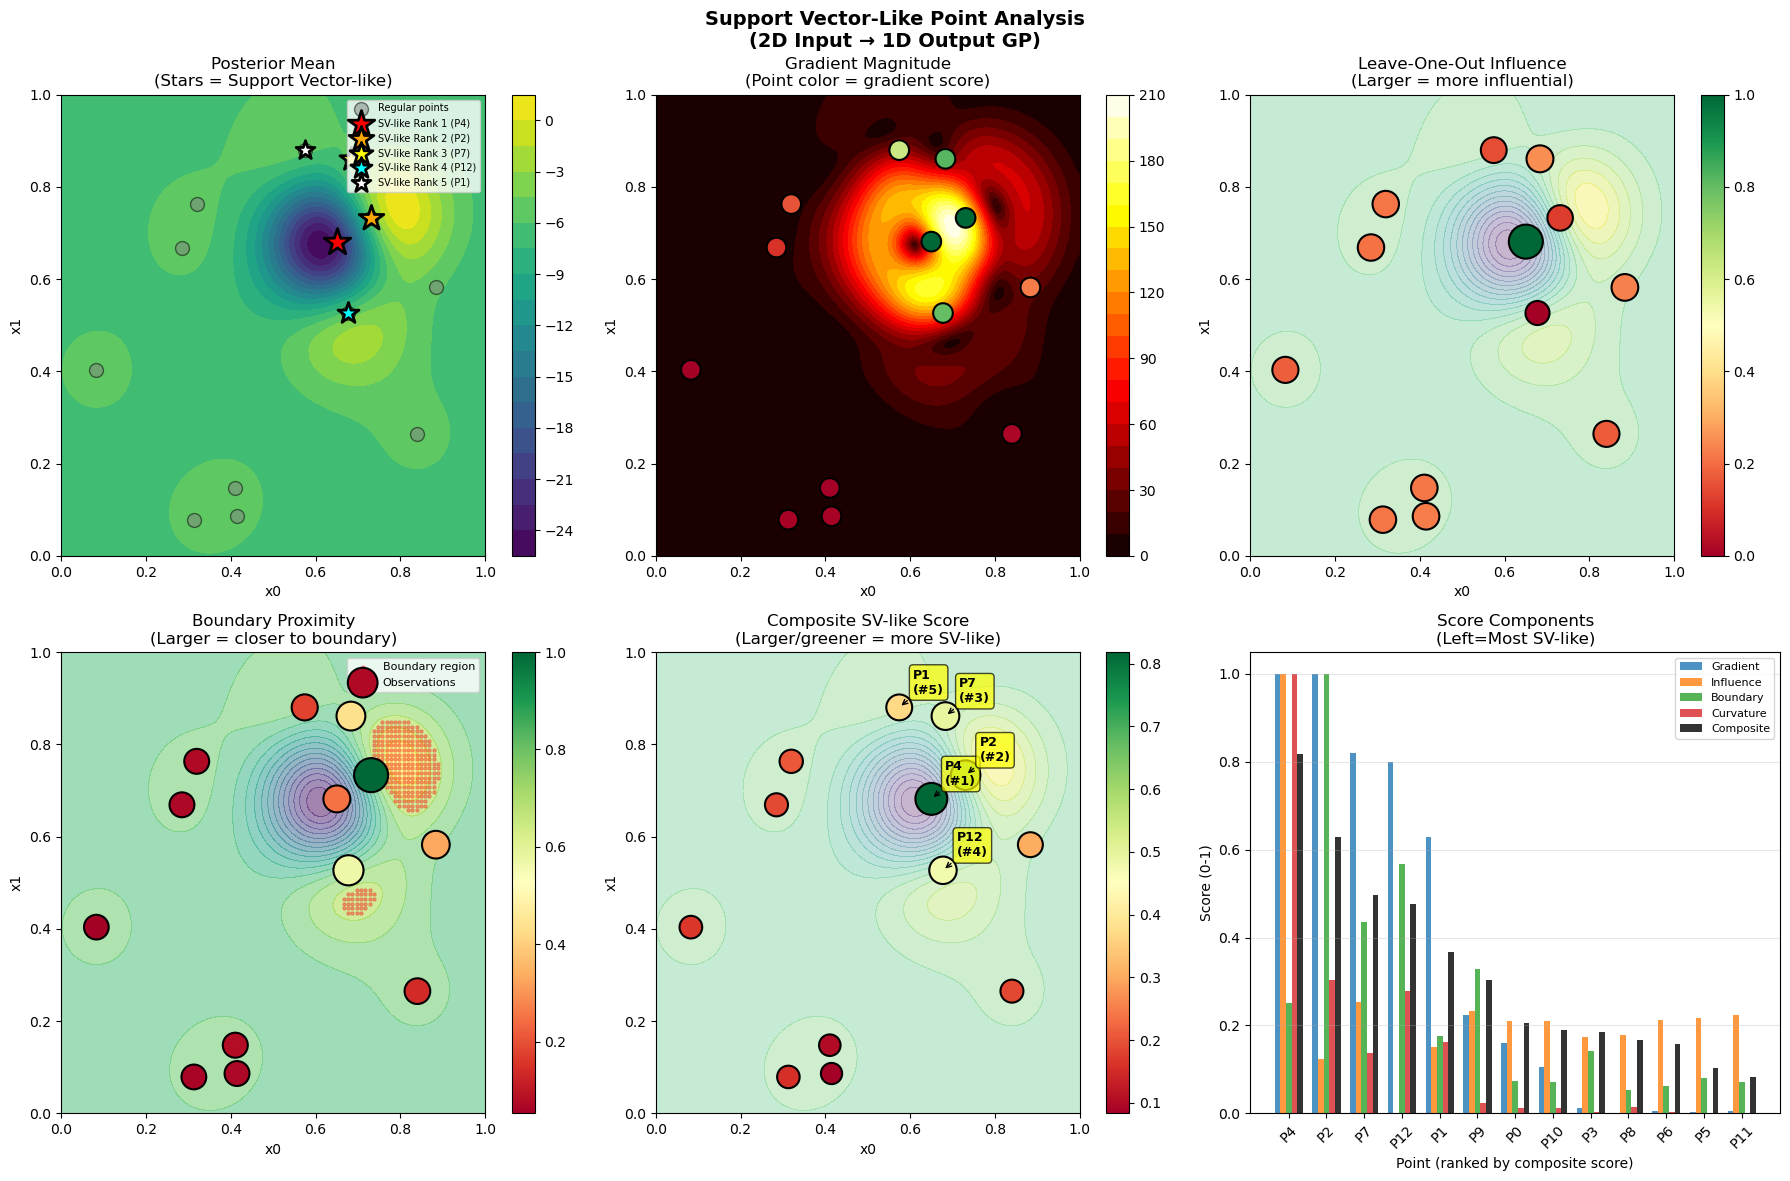


FINAL SUMMARY

Top 5 Support Vector-Like Points:
--------------------------------------------------

Rank 1: P4
  Location: (0.6501, 0.6815)
  Value: -0.0036
  Composite score: 0.8187
  Key characteristic: Gradient (1.0000)

Rank 2: P2
  Location: (0.7310, 0.7330)
  Value: 0.0000
  Composite score: 0.6296
  Key characteristic: Gradient (1.0000)

Rank 3: P7
  Location: (0.6834, 0.8611)
  Value: 0.0000
  Composite score: 0.4960
  Key characteristic: Gradient (0.8198)

Rank 4: P12
  Location: (0.6776, 0.5267)
  Value: 0.0000
  Composite score: 0.4767
  Key characteristic: Gradient (0.7988)

Rank 5: P1
  Location: (0.5743, 0.8799)
  Value: 0.0000
  Composite score: 0.3682
  Key characteristic: Gradient (0.6289)

INTERPRETATION GUIDE:

    HIGH GRADIENT SCORE:
    → Point sits near a steep slope in the objective function
    → Like an SVM support vector near a rapidly changing decision surface
    → Important for defining the shape of the optimization landscape

    HIGH INFLUENCE SCORE:
 

In [16]:
# USAGE
results = identify_support_vector_like_points(
    gp=gp,
    X_obs=X_obs,
    y_obs=y_obs,
    bounds=bounds,
    n_grid=100
)

# Access results
print(f"\nTop support vector-like points:")
for rank, idx in enumerate(results['top_indices']):
    print(f"  Rank {rank+1}: P{idx} at {results['X_obs'][idx]} "
          f"(score: {results['composite_scores'][idx]:.4f})")

In [ ]:
def sv_informed_next_sample(
    gp, X_obs, y_obs, bounds, 
    kappa=3.0, sv_weight=0.4, 
    n_candidates=5000
):
    """
    Select next sample using both UCB AND 
    support-vector-like informativeness.
    
    Standard UCB just uses:
        UCB = mu + kappa * std
    
    SV-informed UCB uses:
        SV_UCB = (1 - sv_weight) * UCB_norm 
               + sv_weight * boundary_score
    
    This finds points that are BOTH:
    - Promising (high UCB)
    - Near important boundaries (high SV score)
    """
    dim = len(bounds)
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    
    # Generate candidates
    X_candidates = np.random.uniform(
        low=lows, high=highs, 
        size=(n_candidates, dim)
    )
    
    # Standard UCB
    mu, std = gp.predict(X_candidates, return_std=True)
    ucb = mu + kappa * std
    
    # Normalize UCB to [0, 1]
    ucb_norm = (ucb - ucb.min()) / (ucb.max() - ucb.min())
    
    # Compute gradient at candidates
    # (proxy for boundary proximity)
    epsilon = 0.01
    gradients = np.zeros(len(X_candidates))
    
    for d in range(dim):
        X_plus = X_candidates.copy()
        X_plus[:, d] += epsilon
        X_minus = X_candidates.copy()
        X_minus[:, d] -= epsilon
        
        # Clip to bounds
        X_plus[:, d] = np.clip(X_plus[:, d], lows[d], highs[d])
        X_minus[:, d] = np.clip(X_minus[:, d], lows[d], highs[d])
        
        mu_plus = gp.predict(X_plus)
        mu_minus = gp.predict(X_minus)
        
        gradients += ((mu_plus - mu_minus) / (2 * epsilon))**2
    
    gradients = np.sqrt(gradients)
    
    # Normalize gradient score
    if gradients.max() > gradients.min():
        grad_norm = (gradients - gradients.min()) / \
                    (gradients.max() - gradients.min())
    else:
        grad_norm = np.zeros_like(gradients)
    
    # Combined acquisition function
    sv_ucb = (1 - sv_weight) * ucb_norm + sv_weight * grad_norm
    
    # Find best candidate
    best_idx = np.argmax(sv_ucb)
    next_point = X_candidates[best_idx]
    
    print("\n" + "="*60)
    print("SV-INFORMED NEXT SAMPLE SELECTION")
    print("="*60)
    print(f"\nStandard UCB would suggest:")
    std_best = np.argmax(ucb_norm)
    print(f"  Point: {X_candidates[std_best]}")
    print(f"  UCB: {ucb[std_best]:.4f}")
    print(f"  Gradient: {gradients[std_best]:.4f}")
    
    print(f"\nSV-Informed UCB suggests:")
    print(f"  Point: {next_point}")
    print(f"  UCB: {ucb[best_idx]:.4f}")
    print(f"  Gradient score: {grad_norm[best_idx]:.4f}")
    print(f"  Combined score: {sv_ucb[best_idx]:.4f}")
    
    # Explain why different
    if not np.allclose(next_point, X_candidates[std_best]):
        print(f"\n  ⭐ Different from standard UCB!")
        print(f"  Reason: SV-informed found a point that is")
        print(f"  BOTH promising AND near an important boundary")
    else:
        print(f"\n  Same as standard UCB - both agree on next point")
    
    return next_point, {
        'ucb': ucb[best_idx],
        'gradient': gradients[best_idx],
        'combined': sv_ucb[best_idx]
    }


# Usage
next_point, info = sv_informed_next_sample(
    gp, X_obs, y_obs, bounds, 
    kappa=3.0, sv_weight=0.4
)